In [10]:
import IPython.display as ipyd
from pyspark.sql.functions import col, regexp_replace, monotonically_increasing_id
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, monotonically_increasing_id, regexp_replace

In [ ]:
spark = SparkSession.builder.getOrCreate()

df = spark.read.parquet("/home/iceberg/data/licitacoes")

df = df.withColumn("id", monotonically_increasing_id())
ids_to_remove = [146031822003, 231928237654, 206158470397, 188979183588]
df = df.filter(~col("id").isin(ids_to_remove))
df_typecasted = df.withColumn("ano", col("ano").cast("int")) \
                  .withColumn("mes", col("mes").cast("int")) \
                  .withColumn("Valor Licitação", regexp_replace(col("Valor Licitação"), ",", ".").cast("float"))
cardinality = sorted([
    (column, df_typecasted.select(F.approx_count_distinct(column)).collect()[0][0])
    for column in df_typecasted.columns if column != "id"
], key=lambda x: x[1])
ordered_cols = [c for c, _ in cardinality]

df_final = df_typecasted.select(ordered_cols) \
                        .orderBy(*[c for c, _ in cardinality])

26/04/13 21:38:29 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

In [13]:
spark.sql("CREATE NAMESPACE IF NOT EXISTS demo.licitacoes")

df_final.writeTo("demo.compras.compras") \
        .tableProperty("format-version", "2") \
        .partitionedBy("ano", "mes") \
        .createOrReplace()

26/04/13 21:40:52 WARN BlockManager: Persisting block taskresult_670 to disk instead.
[Stage 75:>               (0 + 16) / 18][Stage 76:>                (0 + 0) / 28]

[670.101s][warning][gc,alloc] Executor task launch worker for task 10.0 in stage 75.0 (TID 682): Retried waiting for GCLocker too often allocating 131074 words
[670.138s][warning][gc,alloc] Executor task launch worker for task 9.0 in stage 75.0 (TID 681): Retried waiting for GCLocker too often allocating 131074 words


26/04/13 21:41:00 ERROR Executor: Exception in task 10.0 in stage 75.0 (TID 682)
java.lang.OutOfMemoryError: Java heap space
	at org.apache.spark.util.collection.unsafe.sort.UnsafeSorterSpillWriter.<init>(UnsafeSorterSpillWriter.java:55)
	at org.apache.spark.util.collection.unsafe.sort.UnsafeExternalSorter.spill(UnsafeExternalSorter.java:229)
	at org.apache.spark.memory.TaskMemoryManager.trySpillAndAcquire(TaskMemoryManager.java:228)
	at org.apache.spark.memory.TaskMemoryManager.acquireExecutionMemory(TaskMemoryManager.java:191)
	at org.apache.spark.memory.TaskMemoryManager.allocatePage(TaskMemoryManager.java:318)
	at org.apache.spark.memory.MemoryConsumer.allocatePage(MemoryConsumer.java:117)
	at org.apache.spark.util.collection.unsafe.sort.UnsafeExternalSorter.acquireNewPageIfNecessary(UnsafeExternalSorter.java:433)
	at org.apache.spark.util.collection.unsafe.sort.UnsafeExternalSorter.allocateMemoryForRecordIfNecessary(UnsafeExternalSorter.java:452)
	at org.apache.spark.util.collecti

Py4JJavaError: An error occurred while calling o377.createOrReplace.
: org.apache.spark.SparkException: Job 52 cancelled because SparkContext was shut down
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$cleanUpAfterSchedulerStop$1(DAGScheduler.scala:1253)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$cleanUpAfterSchedulerStop$1$adapted(DAGScheduler.scala:1251)
	at scala.collection.mutable.HashSet.foreach(HashSet.scala:79)
	at org.apache.spark.scheduler.DAGScheduler.cleanUpAfterSchedulerStop(DAGScheduler.scala:1251)
	at org.apache.spark.scheduler.DAGSchedulerEventProcessLoop.onStop(DAGScheduler.scala:3087)
	at org.apache.spark.util.EventLoop.stop(EventLoop.scala:84)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$stop$3(DAGScheduler.scala:2973)
	at org.apache.spark.util.Utils$.tryLogNonFatalError(Utils.scala:1375)
	at org.apache.spark.scheduler.DAGScheduler.stop(DAGScheduler.scala:2973)
	at org.apache.spark.SparkContext.$anonfun$stop$12(SparkContext.scala:2258)
	at org

---

In [4]:
df.printSchema()

root
 |-- Número Licitação: string (nullable = true)
 |-- Código UG: string (nullable = true)
 |-- Nome UG: string (nullable = true)
 |-- Código Modalidade Compra: string (nullable = true)
 |-- Modalidade Compra: string (nullable = true)
 |-- Número Processo: string (nullable = true)
 |-- Objeto: string (nullable = true)
 |-- Situação Licitação: string (nullable = true)
 |-- Código Órgão Superior: string (nullable = true)
 |-- Nome Órgão Superior: string (nullable = true)
 |-- Código Órgão: string (nullable = true)
 |-- Nome Órgão: string (nullable = true)
 |-- UF: string (nullable = true)
 |-- Município: string (nullable = true)
 |-- Data Resultado Compra: string (nullable = true)
 |-- Data Abertura: string (nullable = true)
 |-- Valor Licitação: string (nullable = true)
 |-- ano: integer (nullable = true)
 |-- mes: integer (nullable = true)
 |-- id: long (nullable = false)



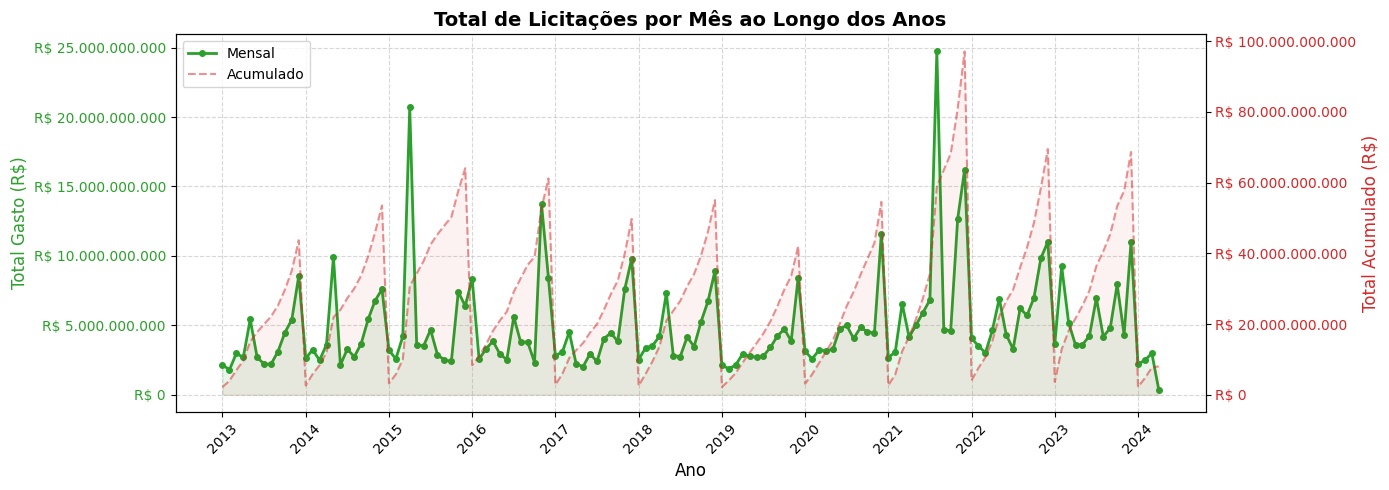

In [7]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum as spark_sum, col

pdf = (
    df_typecasted
      .filter(col("Valor Licitação") > 0)
      .groupBy("ano", "mes")
      .agg(spark_sum("Valor Licitação").alias("total_valor"))
      .orderBy("ano", "mes")
      .toPandas()
)

# Continuous month index
pdf["month_index"] = (pdf["ano"] - pdf["ano"].min()) * 12 + (pdf["mes"] - 1)

# Cumulative sum per year
pdf["cumsum_valor"] = pdf.groupby("ano")["total_valor"].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))

# ── Backdrop: cumsum ──────────────────────────────────────────────────────────
ax2 = ax.twinx()
ax2.fill_between(pdf["month_index"], pdf["cumsum_valor"], alpha=0.06, color="#d62728")
ax2.plot(pdf["month_index"], pdf["cumsum_valor"], linewidth=1.5, color="#d62728", linestyle="--", alpha=0.5, label="Acumulado")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", ".")))
ax2.set_ylabel("Total Acumulado (R$)", fontsize=12, color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

# ── Main: monthly total ───────────────────────────────────────────────────────
ax.plot(pdf["month_index"], pdf["total_valor"], marker="o", linewidth=2, color="#2ca02c", markersize=4, label="Mensal", zorder=3)
ax.fill_between(pdf["month_index"], pdf["total_valor"], alpha=0.1, color="#2ca02c")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", ".")))
ax.set_ylabel("Total Gasto (R$)", fontsize=12, color="#2ca02c")
ax.tick_params(axis="y", labelcolor="#2ca02c")

# ── Year ticks ────────────────────────────────────────────────────────────────
years = pdf.drop_duplicates("ano").sort_values("ano")
tick_positions = ((years["ano"] - pdf["ano"].min()) * 12).tolist()
tick_labels = years["ano"].astype(str).tolist()
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45)

# ── Labels & legend ───────────────────────────────────────────────────────────
ax.set_title("Total de Licitações por Mês ao Longo dos Anos", fontsize=14, fontweight="bold")
ax.set_xlabel("Ano", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()